# Traveling Pharmacist Problem

## Calculate Time and Distances Between Locations

### Configuration

In [ ]:
LOCATION_LIST = "locations.csv"
ORS_API_KEY = '' # Replace with your API Key from https://openrouteservice.org/
USER_AGENT = "traveling-pharmacist-matrix-calc" # Any unique string here is acceptable. Make sure

### Import Pandas

In [2]:
import pandas as pd

### Get Locations

In [ ]:
locations_csv = pd.read_csv(LOCATION_LIST).to_numpy()

locations = []

# Stores the list of locations from the csv file into an array
for i in range(len(locations_csv)):
    locations.append(locations_csv[i][0])

locations

['402 W College Ave, Ada, OH',
 '9 Central Ave, Ada, OH 45810',
 '17 E Auglaize St, Wapakoneta, OH',
 '102 E Auglaize St, Wapakoneta, OH',
 '123 W Auglaize St, Wapakoneta, OH',
 '202 E Auglaize St, Wapakoneta, OH',
 '1001 Fairview Dr, Wapakoneta, OH',
 '1101 Lincoln Ave, Wapakoneta, OH',
 '322 W Franklin St, Kenton, OH',
 '222 W Carrol St, Kenton, OH',
 '620 W Market St, Lima, OH',
 '102 High St, Buckland, OH',
 '306 N Main St, Buckland, OH',
 '400 W 4th St, Lima, OH',
 '327 S Wayne St, St. Marys, OH',
 '101 W Spring St, St. Marys, OH',
 '100 W High St, St. Marys, OH',
 '302 W Chillicothe Ave, Bellefontaine, OH',
 '12065 Geyer Rd, Auglaize, OH',
 '532 W Center St, Marion, OH',
 '912 Cheney Ave, Marion, OH',
 '305 Davids St, Marion, OH',
 '220 E Fairground St, Marion, OH']

### Initalize Services

In [ ]:
from geopy.geocoders import Nominatim
import openrouteservice as ORS

geolocator = Nominatim(user_agent=USER_AGENT, timeout=10) # If an error occurs when trying to find coordinates, increasing the timeout may fix the error.
client = ORS.Client(key=ORS_API_KEY)

### Get Coordinates

In [ ]:
def get_coordinates(location_name):
    # Looks up the coordinates of each location
    location = geolocator.geocode(location_name)

    # Checks if the location was found by the geocoder
    if location:
        return [location.longitude, location.latitude]
    else:
        raise ValueError(f"Could not find coordinates for {location_name}")

# Stores coordiantes in a 2D array
coordinates = [get_coordinates(location) for location in locations]
coordinates

[[-83.8262757, 40.7652237],
 [-83.8216728, 40.7704986],
 [-84.1933913, 40.570444],
 [-84.1924305, 40.570671],
 [-84.1956911, 40.5705338],
 [-84.190977, 40.570577],
 [-84.209489, 40.562266],
 [-84.2028937, 40.580893],
 [-83.6110846, 40.6473373],
 [-83.6100853, 40.649928],
 [-84.1138168, 40.7406108],
 [-84.2596158, 40.6258922],
 [-84.260357, 40.626625],
 [-84.11028, 40.716014],
 [-84.390037, 40.538928],
 [-84.3881167, 40.5427548],
 [-84.389647, 40.543832],
 [-83.7641891, 40.3598971],
 [-84.0740135, 40.5271923],
 [-83.1407606, 40.5893636],
 [-83.1407314, 40.5699819],
 [-83.143462, 40.5842388],
 [-83.1248811, 40.6003622]]

#### Fix Coordinates for ORS

In [ ]:
invCoordinates = []

# Swaps the coordinates' latitude and longitude, as ORS expects to receive them in the opposite order of everything else
for coordinate in coordinates:
    prevPart = None
    i = 0
    for part in coordinate:
        if i > 0:
            i = 0
            invCoordinates.append([part, prevPart])
        else:
            i = i + 1
            prevPart = part

invCoordinates

[[-83.8262757, 40.7652237],
 [-83.8216728, 40.7704986],
 [-84.1933913, 40.570444],
 [-84.1924305, 40.570671],
 [-84.1956911, 40.5705338],
 [-84.190977, 40.570577],
 [-84.209489, 40.562266],
 [-84.2028937, 40.580893],
 [-83.6110846, 40.6473373],
 [-83.6100853, 40.649928],
 [-84.1138168, 40.7406108],
 [-84.2596158, 40.6258922],
 [-84.260357, 40.626625],
 [-84.11028, 40.716014],
 [-84.390037, 40.538928],
 [-84.3881167, 40.5427548],
 [-84.389647, 40.543832],
 [-83.7641891, 40.3598971],
 [-84.0740135, 40.5271923],
 [-83.1407606, 40.5893636],
 [-83.1407314, 40.5699819],
 [-83.143462, 40.5842388],
 [-83.1248811, 40.6003622]]

### Calculate Time and Distances

In [ ]:
# Calls ORS to find the time and distance between locations
response = client.distance_matrix(
    locations=invCoordinates,
    profile='driving-car',
    metrics=['distance', 'duration'],
    sources=list(range(len(locations))),
    destinations=list(range(len(locations))),
    units='km'
)

In [8]:
distances = response['distances']
durations = response['durations']

In [9]:
distances

[[0.0,
  0.95,
  49.23,
  49.26,
  49.42,
  49.02,
  51.69,
  50.78,
  24.53,
  25.04,
  27.64,
  51.62,
  51.47,
  30.46,
  70.03,
  69.59,
  69.32,
  50.51,
  49.23,
  66.41,
  94.88,
  66.58,
  91.04],
 [1.38,
  0.0,
  48.55,
  48.58,
  48.74,
  48.34,
  51.0,
  50.1,
  24.96,
  25.47,
  26.95,
  50.94,
  50.79,
  29.78,
  69.34,
  68.9,
  68.64,
  50.94,
  49.66,
  66.84,
  94.2,
  67.01,
  90.36],
 [51.43,
  50.51,
  0.0,
  0.31,
  0.22,
  0.21,
  2.48,
  1.58,
  55.59,
  55.79,
  24.27,
  9.71,
  9.71,
  21.83,
  20.0,
  19.56,
  19.29,
  51.18,
  13.83,
  97.17,
  143.37,
  97.34,
  139.53],
 [51.37,
  50.45,
  0.09,
  0.0,
  0.28,
  0.14,
  2.55,
  1.64,
  55.53,
  55.73,
  24.21,
  9.78,
  9.78,
  21.76,
  20.06,
  19.62,
  19.36,
  51.12,
  13.77,
  97.1,
  143.3,
  97.27,
  139.46],
 [51.79,
  50.87,
  0.22,
  0.5,
  0.0,
  0.4,
  2.26,
  1.36,
  55.95,
  56.15,
  24.63,
  9.5,
  9.5,
  22.18,
  19.78,
  19.34,
  19.08,
  51.54,
  14.19,
  97.52,
  143.72,
  97.69,
  139.88]

In [10]:
durations

[[0.0,
  99.54,
  2416.33,
  2444.8,
  2431.45,
  2398.21,
  2667.29,
  2536.72,
  1450.69,
  1513.72,
  1689.36,
  2850.91,
  2827.7,
  1726.78,
  3241.89,
  3226.56,
  3193.84,
  2753.16,
  2993.82,
  3830.5,
  4047.95,
  3825.71,
  3753.46],
 [157.21,
  0.0,
  2380.7,
  2409.17,
  2395.82,
  2362.57,
  2631.66,
  2501.09,
  1481.63,
  1544.67,
  1653.73,
  2815.28,
  2792.07,
  1691.15,
  3206.26,
  3190.92,
  3158.21,
  2784.11,
  3024.76,
  3861.44,
  4012.32,
  3856.65,
  3717.83],
 [2505.59,
  2428.71,
  0.0,
  53.72,
  20.04,
  18.13,
  255.88,
  125.31,
  3206.71,
  3249.8,
  1249.06,
  647.04,
  634.55,
  1062.08,
  986.37,
  971.03,
  938.31,
  2641.04,
  1198.35,
  5566.58,
  5840.13,
  5561.79,
  5545.64],
 [2501.45,
  2424.57,
  11.33,
  0.0,
  26.45,
  13.98,
  262.29,
  131.72,
  3202.57,
  3245.66,
  1244.92,
  653.45,
  640.96,
  1057.94,
  992.78,
  977.44,
  944.72,
  2636.9,
  1194.21,
  5562.44,
  5835.99,
  5557.65,
  5541.5],
 [2519.45,
  2442.57,
  20.04,
  68.

### Process Response

In [ ]:
results = []
travelDistances = []
travelTimes = []

for i, origin in enumerate(locations):
    tempDistances = []
    tempTimes = []

    for j, dest in enumerate(locations):
        
        tempDistances.append(round(distances[i][j], 2))
        tempTimes.append(round(durations[i][j] / 60, 2))

        if i != j:
            results.append({
                'From': origin,
                'To': dest,
                'Distance_km': round(distances[i][j], 2),
                'Duration_min': round(durations[i][j] / 60, 2)
            })
            
    travelDistances.append(tempDistances)
    travelTimes.append(tempTimes)

### Save Results to CSV Files

In [ ]:
# Saves data into several csv files so the next sections can be run without running this section again.
df = pd.DataFrame(results)
dfDistance = pd.DataFrame(travelDistances)
dfTime = pd.DataFrame(travelTimes)
dfCoordinate = pd.DataFrame(coordinates)
df.to_csv("matrix.csv", index=False)
dfDistance.to_csv("distances.csv", header=locations, index=False)
dfTime.to_csv("times.csv", header=locations, index=False)

dfCoordinate.to_csv("coordinates.csv", header=["lat", "long"], index=False)

print("Results saved to matrix.csv, distances.csv, times.csv, and coordinates.csv!")

Results saved to matrix.csv, distances.csv, times.csv, and coordinates.csv!


## Calculate Optimal Routes

### Configuration

In [ ]:
LOCATION_LIST = "locations.csv"
NUM_GENERATIONS = 200
POP_SIZE = 50
REFERENCE_ROUTE = "referenceRoute.csv"

### Import Libraries

In [14]:
import numpy as np
import pandas as pd

### Define Problem

In [ ]:
from pymoo.core.problem import ElementwiseProblem

class medClinicTravel(ElementwiseProblem):

    # Initializes the problem
    def __init__(self, locations, distance_matrix, time_matrix):
         
        self.constraint_num = 0

        # Gets number of nodes from adjacency matrix
        self.num_nodes = locations.shape[0]

        print(self.num_nodes)

        # Constraints for each edge being traversed at least once, and Eulerian graph constraints
        super().__init__(n_var=self.num_nodes, n_obj=2, n_constr=self.constraint_num, xl=0, xu=self.num_nodes, vtype=int)

        # Store the adjacency matrix in itself
        #self.pop = pop
        #self.svi = svi
        self.dist_matrix = distance_matrix
        self.time_matrix = time_matrix
        
    
    # Evaluates answers to the problem
    def _evaluate(self, x, out, *args, **kwargs):
        #pop = self.pop
        #svi = self.svi
        dist_matrix = self.dist_matrix
        time_matrix = self.time_matrix
            
        # Objectives
        total_dist = 0
        total_time = 0
        #popsvi = 0
        
        # Calculates Distance and Time between Visited Locations
        for i in range (len(x) - 1):
            node = x[i]
            nextNode = x[i + 1]

            total_dist += dist_matrix[node][nextNode]
            total_time += time_matrix[node][nextNode]
            #popsvi += pop[node] * svi[node]

        # Ensures Algorithm Considers Returning to Start Node
        total_dist += dist_matrix[x[len(x)-1]][0]
        total_time += time_matrix[x[len(x)-1]][0]
        
        out["F"] = np.array([total_dist, total_time]) # The objective is to minimize distance and time traveled.
        
        # Constraints        
        #constraints = []

        #out["G"] = np.array(constraints)

### Optimize Solutions

#### Ensure We Start From the First Location

In [ ]:
from pymoo.core.repair import Repair

class StartFromZeroRepair(Repair):
    def _do(self, problem, X, **kwargs):
        I = np.where(X == 0)[1]

        for k in range(len(X)):
            i = I[k]
            X[k] = np.concatenate([X[k, i:], X[k, :i]])

        return X

#### Solution Algorithm

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling

# Defines the algorithm for creating solutions
algorithm = NSGA2(pop_size=POP_SIZE,
               sampling=PermutationRandomSampling(),
               mutation=InversionMutation(),
               crossover=OrderCrossover(),
               repair=StartFromZeroRepair(),
               eliminate_duplicates=True
               )

#### Define Problem

In [ ]:
# Gets saved data from csv files
locations = pd.read_csv(LOCATION_LIST).to_numpy()
coordinates = pd.read_csv("coordinates.csv")
dist_matrix = pd.read_csv("distances.csv").to_numpy()
time_matrix = pd.read_csv("times.csv").to_numpy()

NameError: name 'pd' is not defined

In [19]:
problem = medClinicTravel(locations, dist_matrix, time_matrix)

23


#### Calculate Optimal Solution

In [ ]:
from pymoo.optimize import minimize

# Generates solutions and attempts to find optimal solutions
results = minimize(
    problem,
    algorithm,
    ('n_gen', NUM_GENERATIONS),
    save_history=True,
    verbose=True
)

F = results.F
history = results.history
output = results.X

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      1 |             - |             -
     2 |      100 |      1 |  0.000000E+00 |             f
     3 |      150 |      1 |  0.000000E+00 |             f
     4 |      200 |      2 |  1.0000000000 |         ideal
     5 |      250 |      2 |  0.7397596942 |         ideal
     6 |      300 |      1 |  1.467100E+02 |         ideal
     7 |      350 |      1 |  0.000000E+00 |             f
     8 |      400 |      2 |  1.0000000000 |         ideal
     9 |      450 |      4 |  0.7950185123 |         ideal
    10 |      500 |      4 |  0.000000E+00 |             f
    11 |      550 |      1 |  4.811000E+01 |         ideal
    12 |      600 |      1 |  0.000000E+00 |             f
    13 |      650 |      2 |  1.5815347722 |         ideal
    14 |      700 |      1 |  2.538000E+01 |         ideal
    15 |      750 |      2 |  1.0000000000 |         ideal
    16 |      800 |      3 |  0.4724935733 |         ide

In [21]:
print([locations[x] for x in output])

[array([['402 W College Ave, Ada, OH'],
       ['222 W Carrol St, Kenton, OH'],
       ['322 W Franklin St, Kenton, OH'],
       ['220 E Fairground St, Marion, OH'],
       ['532 W Center St, Marion, OH'],
       ['305 Davids St, Marion, OH'],
       ['912 Cheney Ave, Marion, OH'],
       ['302 W Chillicothe Ave, Bellefontaine, OH'],
       ['12065 Geyer Rd, Auglaize, OH'],
       ['102 E Auglaize St, Wapakoneta, OH'],
       ['202 E Auglaize St, Wapakoneta, OH'],
       ['17 E Auglaize St, Wapakoneta, OH'],
       ['1101 Lincoln Ave, Wapakoneta, OH'],
       ['123 W Auglaize St, Wapakoneta, OH'],
       ['1001 Fairview Dr, Wapakoneta, OH'],
       ['100 W High St, St. Marys, OH'],
       ['327 S Wayne St, St. Marys, OH'],
       ['101 W Spring St, St. Marys, OH'],
       ['306 N Main St, Buckland, OH'],
       ['102 High St, Buckland, OH'],
       ['400 W 4th St, Lima, OH'],
       ['620 W Market St, Lima, OH'],
       ['9 Central Ave, Ada, OH 45810']], dtype=object), array([['402 W C

In [22]:
# Calculates Distance and Time between Visited Locations
def calculateSolution(solution):
    total_dist = 0
    total_time = 0

    for i in range(len(solution) - 1):
        node = solution[i]
        nextNode = solution[i + 1]

        total_dist += dist_matrix[node][nextNode]
        total_time += time_matrix[node][nextNode]

    # Ensures Algorithm Considers Returning to Start Node
    total_dist += dist_matrix[solution[len(solution)-1]][0]
    total_time += time_matrix[solution[len(solution)-1]][0]

    return [int(total_dist), int(total_time)]

In [ ]:
refList = []

# Calculates Distance and Time between Visited Locations for Reference Point
for city in pd.read_csv(REFERENCE_ROUTE).to_numpy():
    refList.append(city[0])

refPoint = calculateSolution(refList)
        
print("Reference Point: " + str(refPoint))
print("Solution Scores: " + str(results.F))

Reference Point: [350, 350]
Solution Scores: [[305.89 309.45]
 [302.95 318.36]
 [305.97 309.09]
 [306.67 308.5 ]]


### Evaluate Solution

#### Get Result's History

In [24]:
n_evals = []
history_F = []

In [25]:
for algorithm in history:
    n_evals.append(algorithm.evaluator.n_eval)

    opt = algorithm.opt

    feasible = np.where(opt.get("feasible"))[0]
    history_F.append(opt.get("F")[feasible])

#### Calculate Approximate Ideal and Nadir Values

In [26]:
approx_ideal = F.min(axis=0)
approx_nadir = F.max(axis=0)

print("Approx_ideal: " + str(approx_ideal))
print("Approx_nadir: " + str(approx_nadir))

Approx_ideal: [302.95 308.5 ]
Approx_nadir: [306.67 318.36]


#### Calculate Hypervolume

In [27]:
from pymoo.indicators.hv import Hypervolume

metric = Hypervolume(
    ref_point=np.array(refPoint),
    norm_ref_point=False,
    zero_to_one=True,
    ideal=approx_ideal,
    nadir=approx_nadir
)

hv = [metric.do(_F) for _F in history_F]

#### Visualize Hypervolume

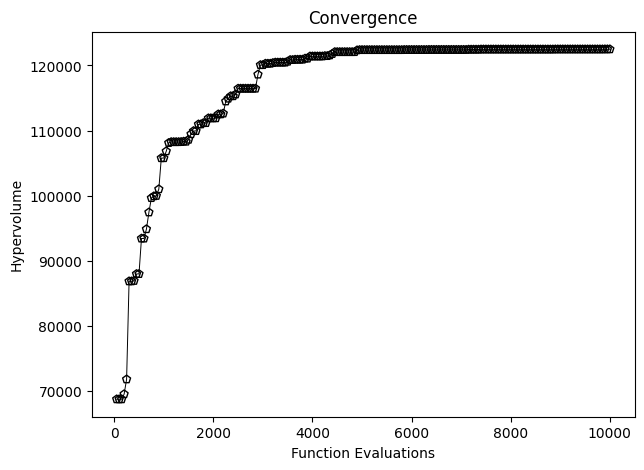

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(n_evals, hv, color='black', lw=0.7, label="Average CV of Pop")
plt.scatter(n_evals, hv, facecolor="none", edgecolor='black', marker="p")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.ylabel("Hypervolume")
plt.show()

#### Pareto Front of Solutions

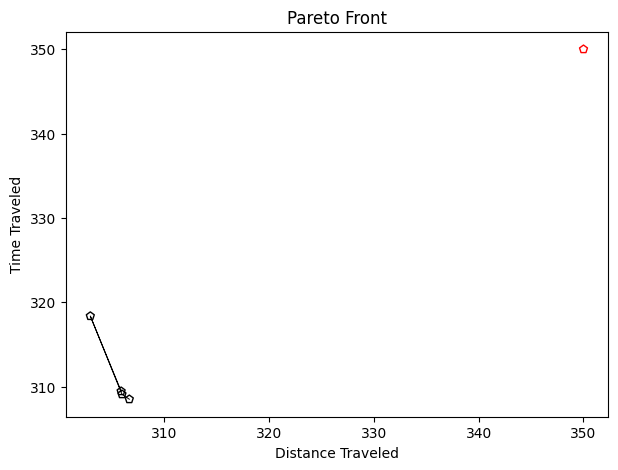

In [29]:
i = 0
j = 0
x = []
y = []


for solution in F:
    if i > 0 and solution[0] < x[i - 1]:
        j = i
        while i > 1 and solution[0] < x[i - 1]:
            i = i - 1
        
        x.insert(i, solution[0])
        y.insert(i, solution[1])
    else:
        x.append(solution[0])
        y.append(solution[1])

    if j != 0:
        i = j
        j = 0
    
    i = i + 1



plt.figure(figsize=(7, 5))
plt.plot(x, y, color='black', lw=0.7, label="Pareto Front")
plt.scatter(x, y, facecolor="none", edgecolor='black', marker="p")
plt.scatter(refPoint[0], refPoint[1], facecolor="none", edgecolor='red', marker="p")
plt.title("Pareto Front")
plt.xlabel("Distance Traveled")
plt.ylabel("Time Traveled")
plt.show()

## Display Map

### Configuration

In [ ]:
ORS_API_KEY = '' # Replace with your API Key from https://openrouteservice.org/
RATE_LIMIT = 60 # Enter your per minute quota for your plan here
SOLUTION_TO_MAP = 0

### Setup Map and ORS

In [ ]:
import folium
import openrouteservice as ORS

client = ORS.Client(key=ORS_API_KEY)

# Creates the map
map = folium.Map(
    location=[coordinates['lat'].mean(),coordinates['long'].mean()], 
    zoom_start=7
) 

### Draw Routes

In [ ]:
import time

# Creates routes between each location
for i in range(len(locations) - 1):
    visitedLocation = results.X[SOLUTION_TO_MAP][i]
    nextLocation = results.X[SOLUTION_TO_MAP][i + 1]

    response = client.directions(
        coordinates=[[coordinates.iloc[visitedLocation,1], coordinates.iloc[visitedLocation,0]], [coordinates.iloc[nextLocation,1], coordinates.iloc[nextLocation,0]]],
        profile='driving-car',
        format='geojson'
    )

    time.sleep(RATE_LIMIT/60)

    folium.Choropleth(
        geo_data=response,
        line_color="black",
        line_weight=5
    ).add_to(map)

# Creates final route from last visited location back to origin
response = client.directions(
    coordinates=[[coordinates.iloc[results.X[SOLUTION_TO_MAP][len(locations)-1],1], coordinates.iloc[results.X[SOLUTION_TO_MAP][len(locations)-1],0]], [coordinates.iloc[0,1], coordinates.iloc[0,0]]],
    profile='driving-car',
    format='geojson'
)

folium.Choropleth(
    geo_data=response,
    line_color="red",
    line_weight=5
).add_to(map)


### Set Bounds

In [33]:
sw = coordinates.loc[:,['lat', 'long']].min().values.tolist()
ne = coordinates.loc[:,['lat', 'long']].max().values.tolist()
map.fit_bounds([sw,ne])

### Draw Points

In [ ]:
# Creates a point for every location visited and the order in which they are visited.
for i in range(len(results.X[SOLUTION_TO_MAP])):
    location = locations[results.X[SOLUTION_TO_MAP][i]]
    folium.CircleMarker(
        location=(coordinates.iloc[i,0], coordinates.iloc[i,1]),
        tooltip=str(np.where(results.X[SOLUTION_TO_MAP] == i)[0]) + ", " + locations[i],
        radius=10,
        color="black",
        fill=False
    ).add_to(map)

### Display Map

In [35]:
display(map)